<a href="https://colab.research.google.com/github/Garvitjaiswal12/Household-income-prediction-EDA-Modeling/blob/main/%F0%9F%8F%A0%F0%9F%92%B0Household_Income.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('data.csv')
df


,Age,Education_Level,Occupation,Number_of_Dependents,Location,Work_Experience,Marital_Status,Employment_Status,Household_Size,Homeownership_Status,Type_of_Housing,Gender,Primary_Mode_of_Transportation,Income
0,56,Master's,Technology,5,Urban,21,Married,Full-time,7,Own,Apartment,Male,Public transit,72510
1,69,High School,Finance,0,Urban,4,Single,Full-time,7,Own,Apartment,Male,Biking,75462
2,46,Bachelor's,Technology,1,Urban,1,Single,Full-time,7,Own,Single-family home,Female,Car,71748
3,32,High School,Others,2,Urban,32,Married,Full-time,1,Own,Apartment,Female,Car,74520
4,60,Bachelor's,Finance,3,Urban,15,Married,Self-employed,4,Own,Townhouse,Male,Walking,640210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,58,High School,Others,0,Suburban,26,Divorced,Full-time,6,Own,Townhouse,Female,Car,74994
9996,23,Master's,Technology,3,Urban,16,Divorced,Full-time,1,Own,Single-family home,Female,Biking,72676
9997,41,Doctorate,Education,3,Urban,50,Single,Full-time,4,Own,Single-family home,Female,Public transit,2684820
9998,44,High School,Education,0,Urban,3,Married,Part-time,1,Own,Single-family home,Male,Biking,57955


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Age                             10000 non-null  int64 
 1   Education_Level                 10000 non-null  object
 2   Occupation                      10000 non-null  object
 3   Number_of_Dependents            10000 non-null  int64 
 4   Location                        10000 non-null  object
 5   Work_Experience                 10000 non-null  int64 
 6   Marital_Status                  10000 non-null  object
 7   Employment_Status               10000 non-null  object
 8   Household_Size                  10000 non-null  int64 
 9   Homeownership_Status            10000 non-null  object
 10  Type_of_Housing                 10000 non-null  object
 11  Gender                          10000 non-null  object
 12  Primary_Mode_of_Transportation  10000 non-null 

In [ ]:
df.describe()

,Age,Number_of_Dependents,Work_Experience,Household_Size,Income
count,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04
mean,44.021700,2.527000,24.858800,3.989600,8.168382e+05
std,15.203998,1.713991,14.652622,2.010496,1.821089e+06
min,18.000000,0.000000,0.000000,1.000000,3.104400e+04
25%,31.000000,1.000000,12.000000,2.000000,6.844600e+04
50%,44.000000,3.000000,25.000000,4.000000,7.294300e+04
75%,57.000000,4.000000,37.000000,6.000000,3.506675e+05
max,70.000000,5.000000,50.000000,7.000000,9.992571e+06


In [ ]:
df.isnull().sum()

,0
Age,0
Education_Level,0
Occupation,0
Number_of_Dependents,0
Location,0
Work_Experience,0
Marital_Status,0
Employment_Status,0
Household_Size,0
Homeownership_Status,0


In [ ]:
categorical_col = df.select_dtypes(include='object').columns.tolist()
categorical_col

['Education_Level',
 'Occupation',
 'Location',
 'Marital_Status',
 'Employment_Status',
 'Homeownership_Status',
 'Type_of_Housing',
 'Gender',
 'Primary_Mode_of_Transportation']

In [ ]:
numerical_col=df.select_dtypes(include='number').columns.tolist()
numerical_col

['Age', 'Number_of_Dependents', 'Work_Experience', 'Household_Size', 'Income']

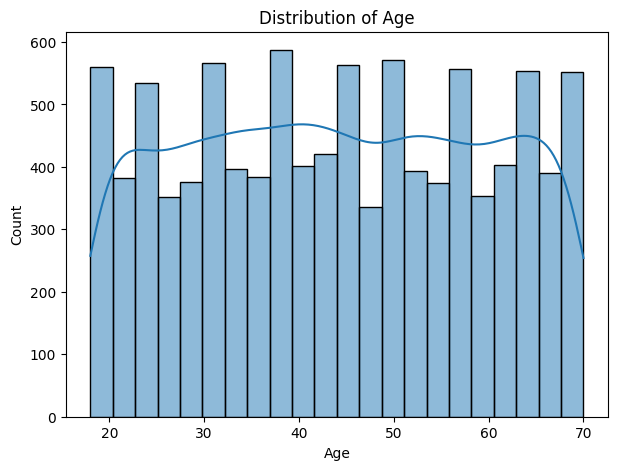

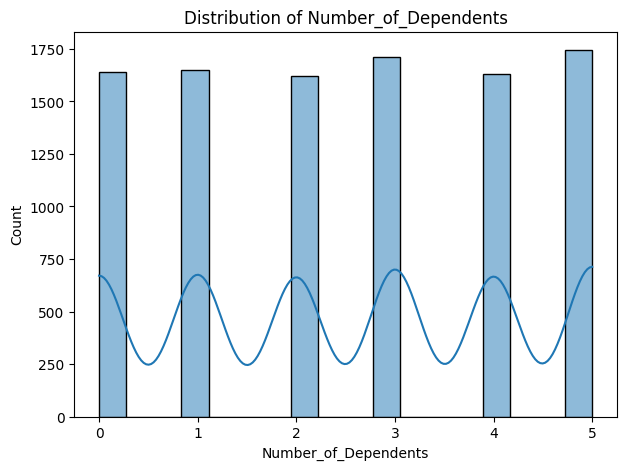

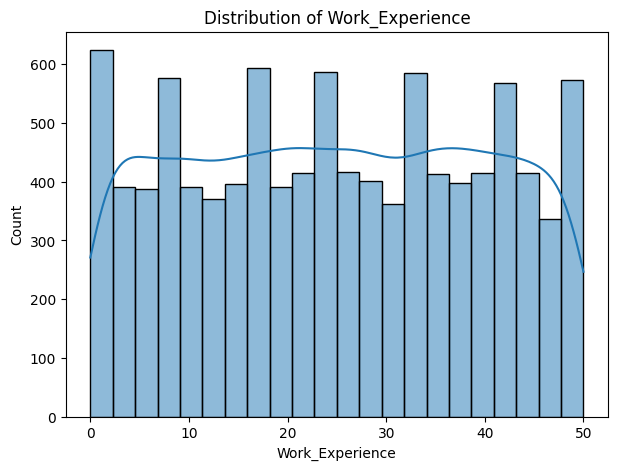

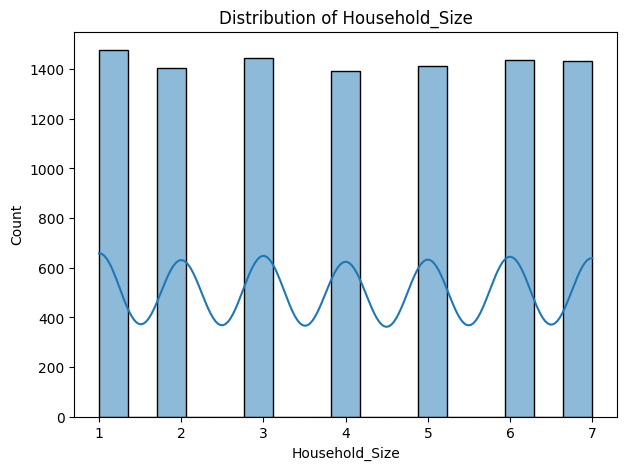

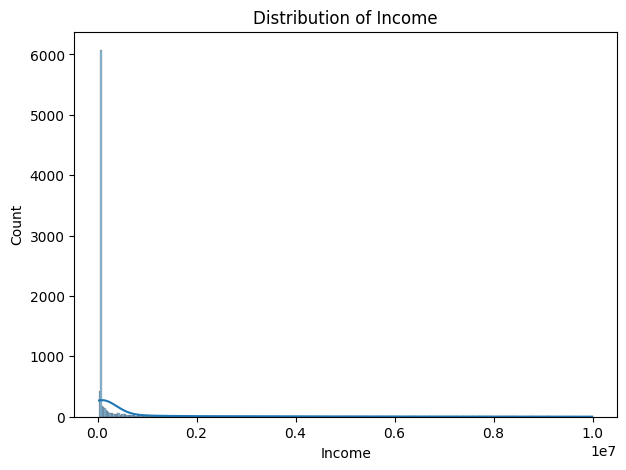

In [ ]:
numerical_col=['Age', 'Number_of_Dependents', 'Work_Experience', 'Household_Size', 'Income']
for col in numerical_col:
  plt.figure(figsize=(7,5))
  sns.histplot(df[col],kde=True)
  plt.title(f'Distribution of {col}')
  plt.show()

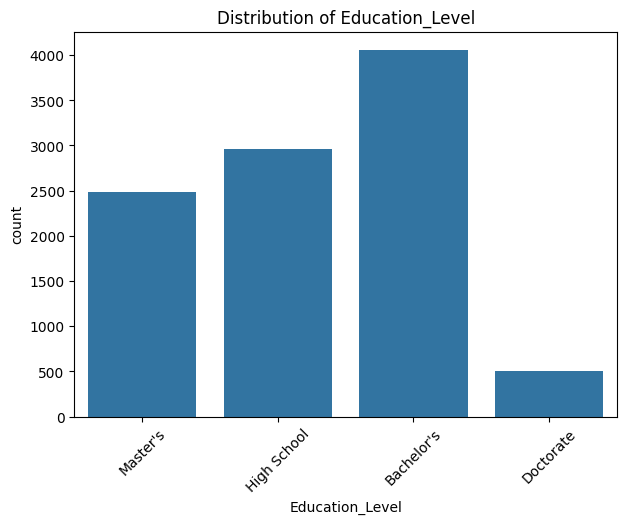

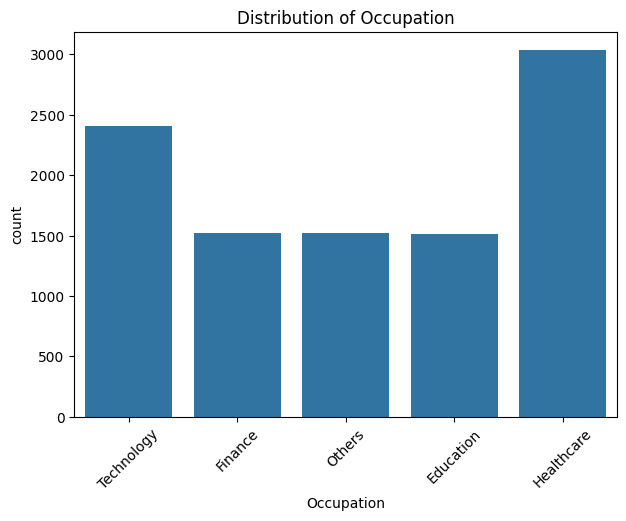

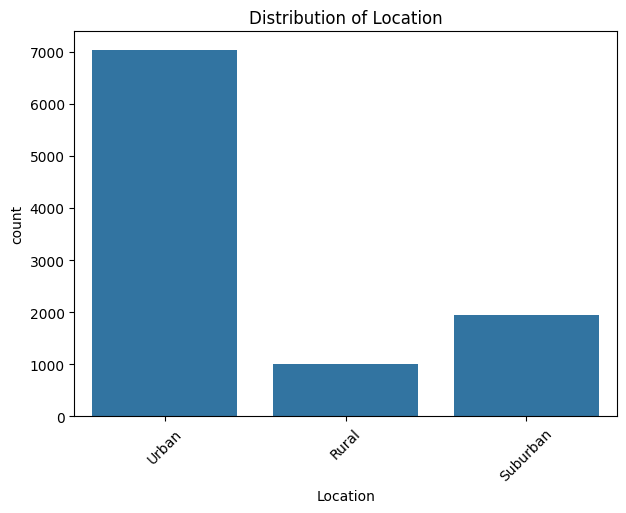

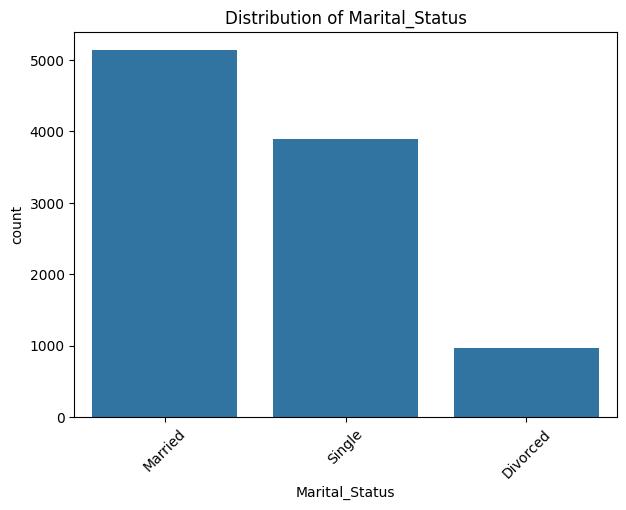

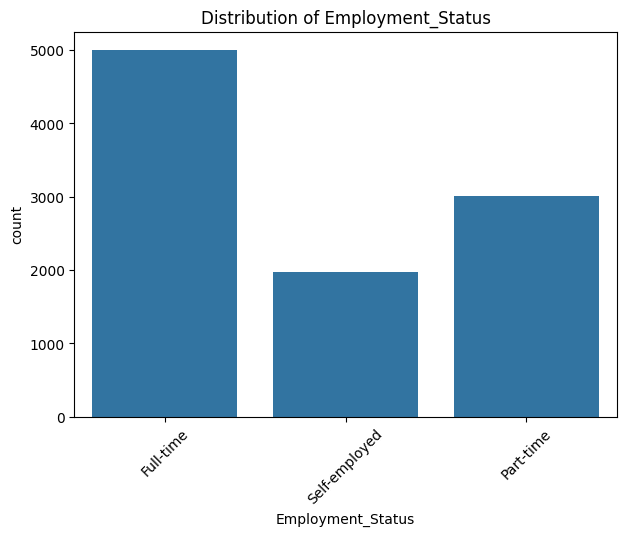

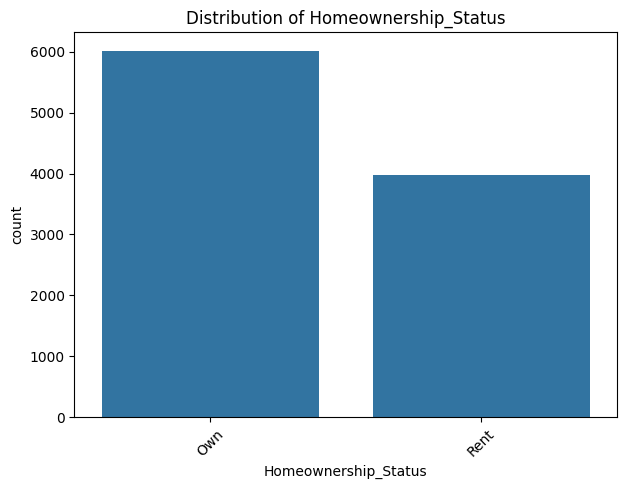

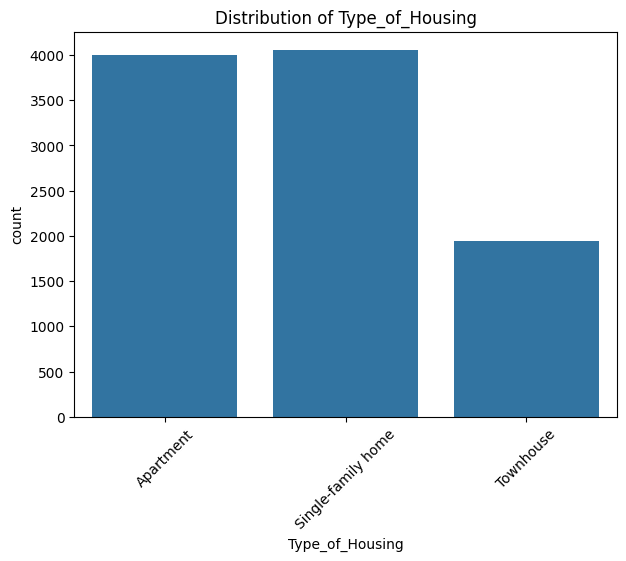

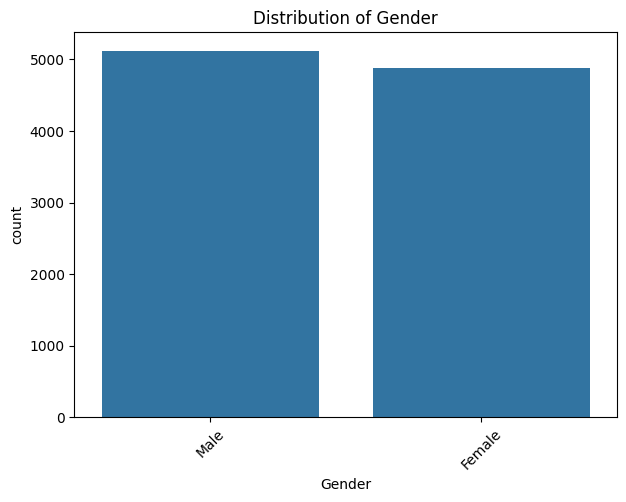

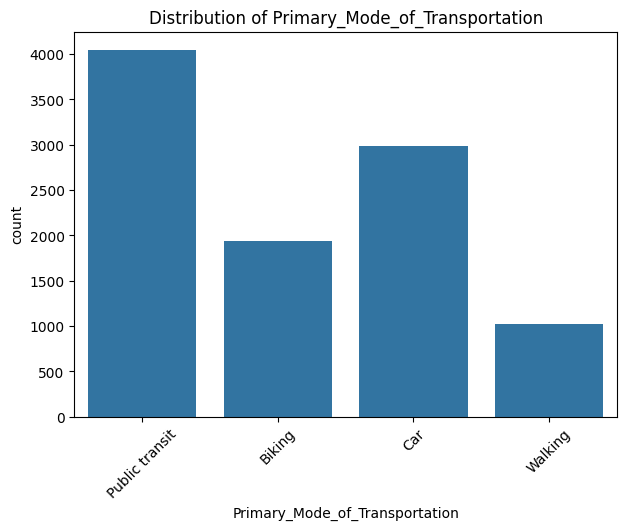

In [ ]:
categorical_col=['Education_Level',
 'Occupation',
 'Location',
 'Marital_Status',
 'Employment_Status',
 'Homeownership_Status',
 'Type_of_Housing',
 'Gender',
 'Primary_Mode_of_Transportation']
for col in categorical_col:
  plt.figure(figsize=(7,5))
  sns.countplot(x=col,data=df)
  plt.xticks(rotation=45)
  plt.title(f'Distribution of {col}')
  plt.show()

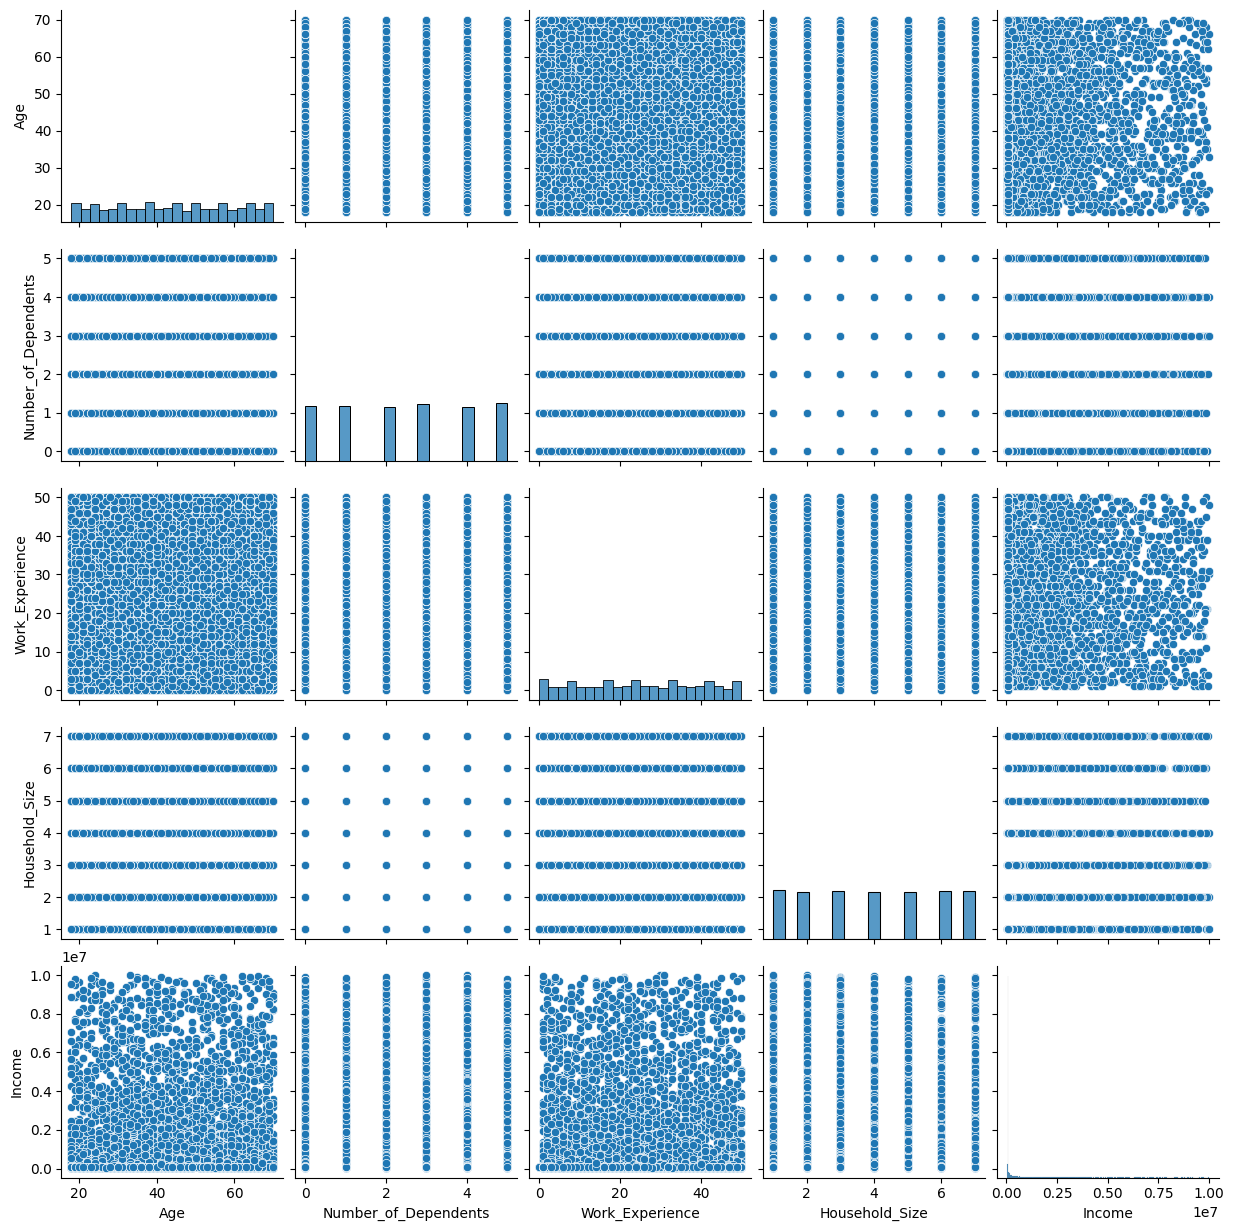

In [ ]:
# Pair plot for numerical features
sns.pairplot(df[numerical_col])
plt.show()

In [ ]:
X=df.drop('Income',axis=1)
y=df['Income']

In [ ]:
# Identify categorical and numerical columns based on unique values
categorical_cols = ['Education_Level', 'Occupation', 'Location', 'Marital_Status',
                    'Employment_Status', 'Homeownership_Status', 'Type_of_Housing',
                    'Gender', 'Primary_Mode_of_Transportation']

numerical_cols = ['Age', 'Number_of_Dependents', 'Work_Experience', 'Household_Size']

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoders={col:LabelEncoder() for col in categorical_cols}

In [ ]:
for col in categorical_cols:
    X[col] = label_encoders[col].fit_transform(X[col])

In [ ]:
from sklearn.preprocessing import StandardScaler
se=StandardScaler()
for col in numerical_cols:
  X[col]=se.fit_transform(X[[col]])

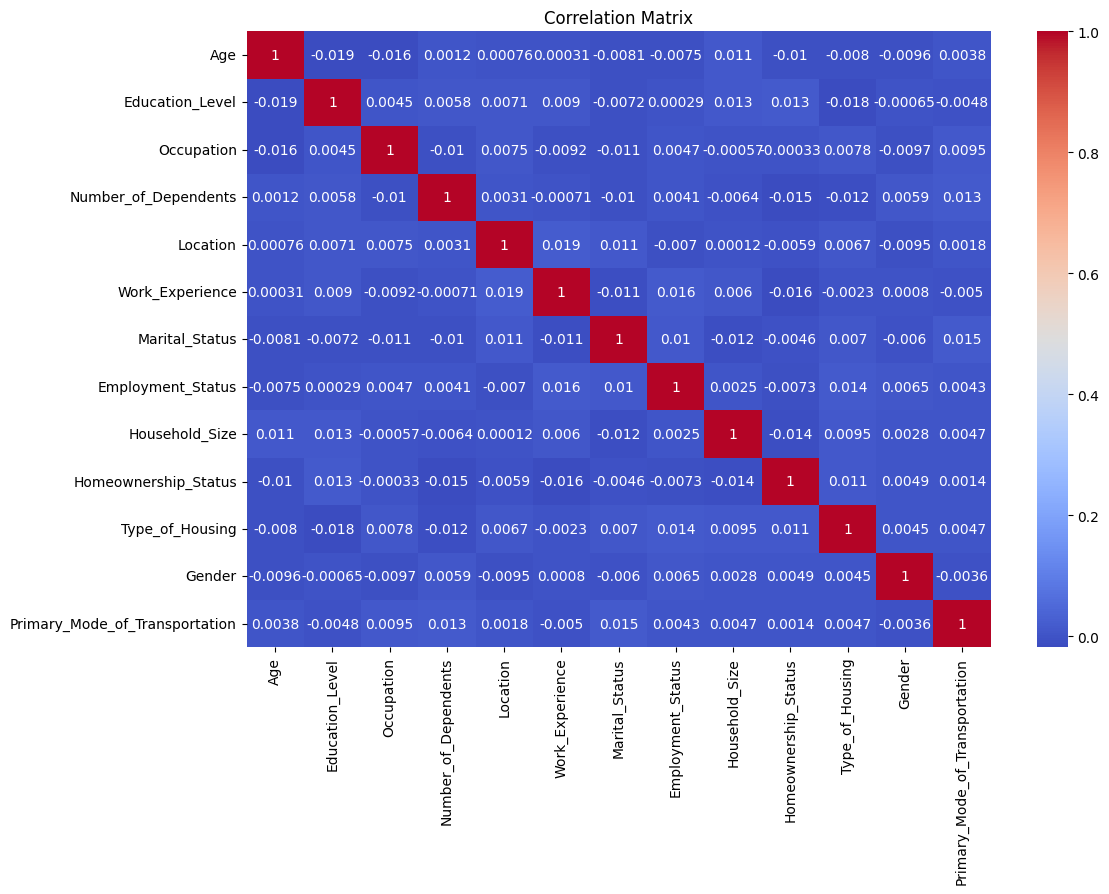

In [ ]:
# correlation matrix
correlation_matrix = X.corr()
# Plotting the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
 X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

IndentationError: unexpected indent (1900681182.py, line 2)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    adjusted_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)
    return mse, rmse, mae, r2, adjusted_r2

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
lr=LinearRegression()
lr.fit(X_train,y_train)
mse, rmse, mae, r2, adjusted_r2=evaluate_model(lr,X_test,y_test)
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R2 Score: {r2}")
print(f"Adjusted R2 Score: {adjusted_r2}")

MSE: 3146273932318.6016
RMSE: 1773773.9236775925
MAE: 1105080.9813969913
R2 Score: 0.0027222467799987715
Adjusted R2 Score: -0.0038057546257717068


In [ ]:
dt=DecisionTreeRegressor()
dt.fit(X_train,y_train)
mse, rmse, mae, r2, adjusted_r2=evaluate_model(dt,X_test,y_test)
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R2 Score: {r2}")
print(f"Adjusted R2 Score: {adjusted_r2}")

MSE: 7125291211074.962
RMSE: 2669324.1112826597
MAE: 1393776.4535
R2 Score: -1.2585110396863866
Adjusted R2 Score: -1.2732948481032662


In [ ]:
rf=RandomForestRegressor()
rf.fit(X_train,y_train)
mse, rmse, mae, r2, adjusted_r2=evaluate_model(rf,X_test,y_test)
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R2 Score: {r2}")
print(f"Adjusted R2 Score: {adjusted_r2}")

MSE: 3221517081054.5854
RMSE: 1794858.5128233884
MAE: 1189285.6570149998
R2 Score: -0.02112765311136955
Adjusted R2 Score: -0.02781177168662019


In [ ]:
svr=SVR()
svr.fit(X_train,y_train)
mse, rmse, mae, r2, adjusted_r2=evaluate_model(svr,X_test,y_test)
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R2 Score: {r2}")
print(f"Adjusted R2 Score: {adjusted_r2}")
#

MSE: 3714668177352.6826
RMSE: 1927347.4459351336
MAE: 754280.6699768894
R2 Score: -0.17744227411823
Adjusted R2 Score: -0.18514960018244797


In [ ]:
knr=KNeighborsRegressor()
knr.fit(X_train,y_train)
mse, rmse, mae, r2, adjusted_r2=evaluate_model(knr,X_test,y_test)
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R2 Score: {r2}")
print(f"Adjusted R2 Score: {adjusted_r2}")
#

MSE: 3605218038445.4214
RMSE: 1898741.1720520048
MAE: 1109678.9568
R2 Score: -0.1427497486207403
Adjusted R2 Score: -0.15022998363185303


In [ ]:
gb=GradientBoostingRegressor()
gb.fit(X_train,y_train)
mse, rmse, mae, r2, adjusted_r2=evaluate_model(gb,X_test,y_test)
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R2 Score: {r2}")
print(f"Adjusted R2 Score: {adjusted_r2}")

MSE: 3121045736614.679
RMSE: 1766648.164353808
MAE: 1099458.1042094827
R2 Score: 0.010718854472343331
Adjusted R2 Score: 0.004243197427096779


In [ ]:
# hyper parameter tunning
from sklearn.model_selection import GridSearchCV
# Define the Gradient Boosting Regressor model
gb_model = GradientBoostingRegressor(random_state=42)
# Parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.5],
    'max_depth': [3, 5, 7]
}

In [ ]:
# Perform GridSearchCV
grid_search = GridSearchCV(estimator=gb_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


GridSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.5],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300]},
             scoring='neg_mean_squared_error', verbose=1)

In [ ]:
# Best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Lowest MSE found: ", np.abs(grid_search.best_score_))

Best parameters found:  {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 100}
Lowest MSE found:  3280949293246.923


In [ ]:
# Initialize the Gradient Boosting Regressor with best parameters
best_gb_model = grid_search.best_estimator_

In [ ]:
# Evaluate the model
best_gb_model.fit(X_train, y_train)
predictions = best_gb_model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
adjusted_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)
print(f'Gradient Boosting Regressor - MSE: {mse}, RMSE: {rmse}, MAE: {mae}, R2: {r2},adj_r2={adjusted_r2}')

Gradient Boosting Regressor - MSE: 3089800329857.619, RMSE: 1757782.7880195037, MAE: 1097780.6575595739, R2: 0.020622743872769078,adj_r2=0.014211915912218265


In [ ]:
import joblib
joblib.dump(best_gb_model,'model.pkl')

['model.pkl']

In [ ]:
git init
git add app.py model.pkl
git commit -m "Initial commit: income predictor app"
git branch -M main
git remote add origin https://github.com/Garvitjaiswal12/Household-income-prediction-EDA-Modeling.git
git push -u origin main